In [1]:
import torch

print(torch.__version__)

print(torch.cuda.is_available())

2.5.1+cu121
True


In [2]:
import sys

print(sys.executable)

C:\Users\hp\AppData\Local\Programs\Python\Python310\python.exe



GPU CHECK
Torch Version: 2.5.1+cu121
CUDA Available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU

VALID TRAINING PAIRS: 57

LOADING DEEPLABV3+
cuda:0

TRAINING STARTED

Epoch 1/100 Loss: 0.8714
Epoch 2/100 Loss: 0.8546
Epoch 3/100 Loss: 0.8386
Epoch 4/100 Loss: 0.8187
Epoch 5/100 Loss: 0.7955
Epoch 6/100 Loss: 0.7739
Epoch 7/100 Loss: 0.7537
Epoch 8/100 Loss: 0.7298
Epoch 9/100 Loss: 0.7136
Epoch 10/100 Loss: 0.6958
Epoch 11/100 Loss: 0.6827
Epoch 12/100 Loss: 0.6679
Epoch 13/100 Loss: 0.6537
Epoch 14/100 Loss: 0.6444
Epoch 15/100 Loss: 0.6355
Epoch 16/100 Loss: 0.6206
Epoch 17/100 Loss: 0.6130
Epoch 18/100 Loss: 0.6026
Epoch 19/100 Loss: 0.6001
Epoch 20/100 Loss: 0.5915
Epoch 21/100 Loss: 0.5889
Epoch 22/100 Loss: 0.5825
Epoch 23/100 Loss: 0.5698
Epoch 24/100 Loss: 0.5651
Epoch 25/100 Loss: 0.5626
Epoch 26/100 Loss: 0.5561
Epoch 27/100 Loss: 0.5544
Epoch 28/100 Loss: 0.5503
Epoch 29/100 Loss: 0.5445
Epoch 30/100 Loss: 0.5392
Epoch 31/100 Loss: 0.5360
Epoch 32/100 Loss: 0.5373
Ep

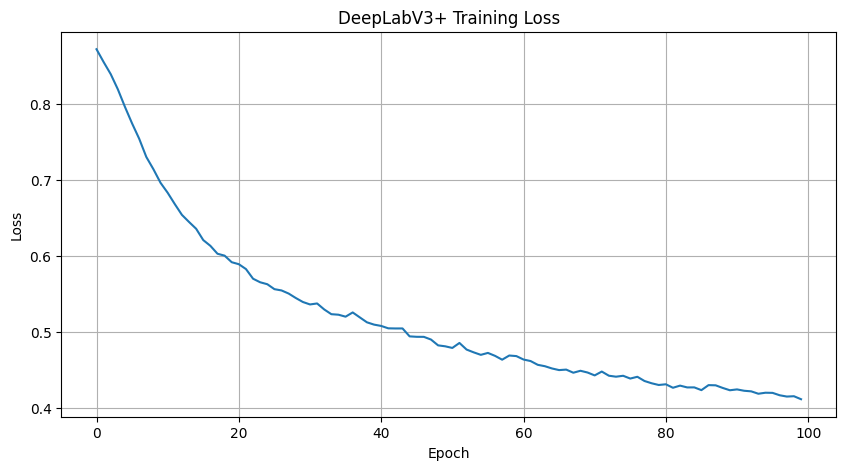


PREDICTING



100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:04<00:00, 11.24it/s]



PREDICTION COMPLETE

VISUALIZATION


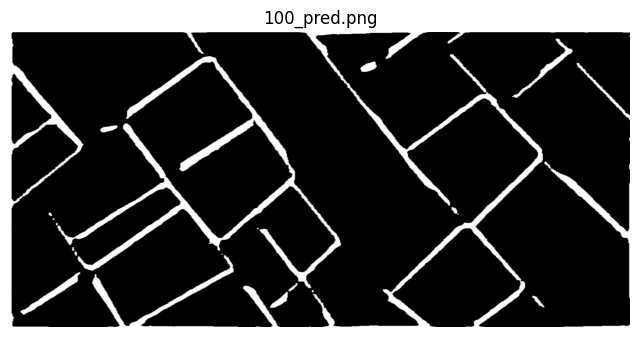

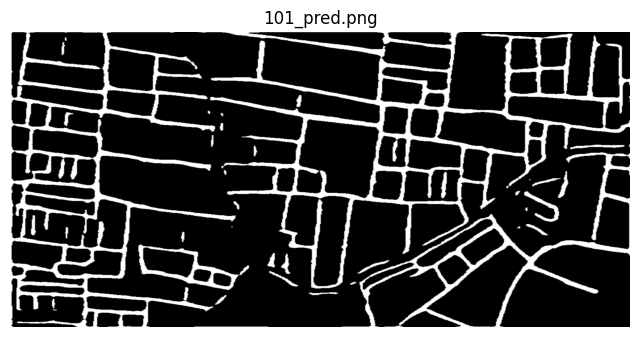

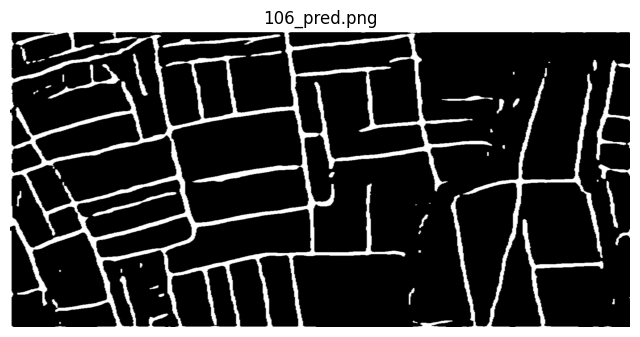

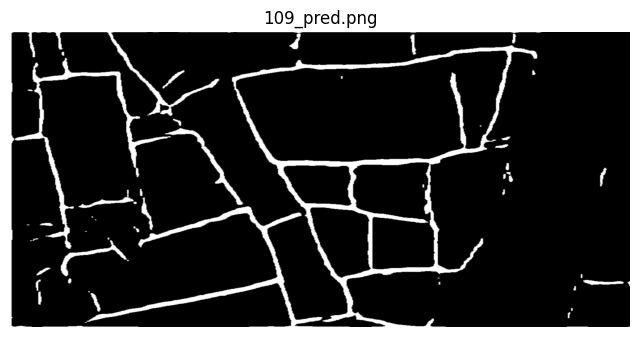

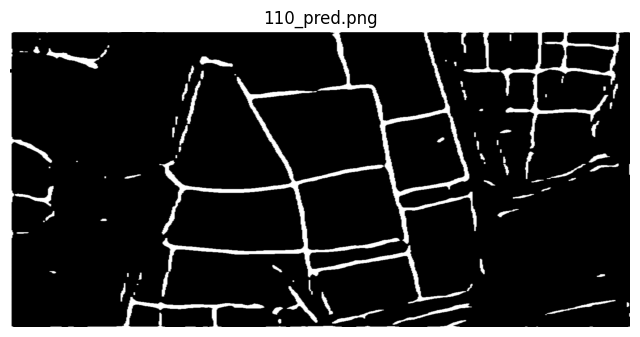


CALCULATING METRICS

FINAL METRICS

IoU Score       : nan
Dice Score      : nan
Precision Score : nan
Recall Score    : nan


C:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


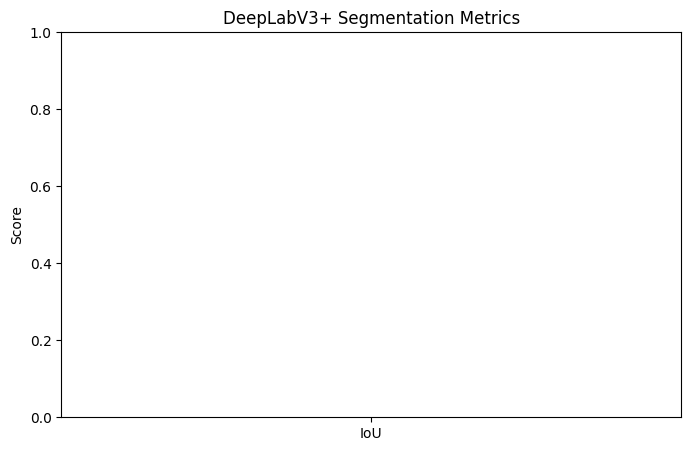


PIPELINE COMPLETE


In [3]:
# ============================================================
# DEEPLABV3+ FARMLAND BOUNDARY SEGMENTATION
# FINAL GPU VERSION
# ============================================================

# ============================================================
# INSTALL REQUIRED LIBRARIES
# ============================================================

# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# pip install segmentation-models-pytorch
# pip install opencv-python
# pip install matplotlib
# pip install tqdm

# ============================================================
# IMPORTS
# ============================================================

import os
import cv2
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

from glob import glob
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import segmentation_models_pytorch as smp

# ============================================================
# GPU CHECK
# ============================================================

print("\n===================================")
print("GPU CHECK")
print("===================================")

print("Torch Version:", torch.__version__)

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU:", torch.cuda.get_device_name(0))

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# PATHS
# ============================================================

TRAIN1_IMAGES = r"D:\farmland boundary\New folder\Train\farmlands"

TRAIN2_IMAGES = r"D:\farmland boundary\New folder\Train 2\images"

MASK_FOLDER = r"D:\farmland boundary\all_boundary_masks"

PREDICT_IMAGES = r"D:\farmland boundary\New folder\images"

PREDICTION_FOLDER = r"D:\farmland boundary\deeplab_predictions"

MODEL_PATH = r"D:\farmland boundary\deeplabv3plus_boundary.pth"

os.makedirs(PREDICTION_FOLDER, exist_ok=True)

# ============================================================
# SETTINGS
# ============================================================

IMAGE_SIZE = 768

BATCH_SIZE = 4

EPOCHS = 100

LEARNING_RATE = 1e-4

# ============================================================
# NORMALIZE FILENAMES
# ============================================================

def normalize_name(name):

    name = os.path.splitext(name)[0]

    name = name.lower()

    name = name.replace("- copy", "")

    name = name.replace(" ", "")

    name = name.strip()

    return name

# ============================================================
# DATASET
# ============================================================

class FarmlandDataset(Dataset):

    def __init__(self, image_folders, mask_folder):

        self.samples = []

        # ====================================================
        # LOAD ALL MASKS
        # ====================================================

        mask_paths = glob(
            os.path.join(mask_folder, "*.png")
        )

        mask_dict = {}

        for mask_path in mask_paths:

            mask_name = normalize_name(
                os.path.basename(mask_path)
            )

            mask_dict[mask_name] = mask_path

        # ====================================================
        # MATCH IMAGES WITH MASKS
        # ====================================================

        for folder in image_folders:

            image_paths = sorted(

                glob(os.path.join(folder, "*.jpg")) +

                glob(os.path.join(folder, "*.png")) +

                glob(os.path.join(folder, "*.jpeg"))
            )

            for image_path in image_paths:

                image_name = normalize_name(
                    os.path.basename(image_path)
                )

                if image_name in mask_dict:

                    self.samples.append(

                        (
                            image_path,
                            mask_dict[image_name]
                        )
                    )

        print(f"\nVALID TRAINING PAIRS: {len(self.samples)}")

        self.transform = transforms.Compose([

            transforms.ToTensor()

        ])

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        image_path, mask_path = self.samples[idx]

        # ====================================================
        # LOAD IMAGE
        # ====================================================

        image = cv2.imread(image_path)

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        # ====================================================
        # LOAD MASK
        # ====================================================

        mask = cv2.imread(mask_path, 0)

        # ====================================================
        # RESIZE
        # ====================================================

        image = cv2.resize(
            image,
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        mask = cv2.resize(
            mask,
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        # ====================================================
        # NORMALIZE
        # ====================================================

        image = self.transform(image)

        mask = torch.tensor(
            mask / 255.0
        ).float().unsqueeze(0)

        return image, mask

# ============================================================
# LOAD DATASET
# ============================================================

dataset = FarmlandDataset(

    [TRAIN1_IMAGES, TRAIN2_IMAGES],

    MASK_FOLDER
)

# ============================================================
# CHECK DATASET
# ============================================================

if len(dataset) == 0:

    raise ValueError(
        "NO VALID IMAGE-MASK PAIRS FOUND"
    )

# ============================================================
# DATALOADER
# ============================================================

loader = DataLoader(

    dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    drop_last=True
)

# ============================================================
# LOAD MODEL
# ============================================================

print("\n===================================")
print("LOADING DEEPLABV3+")
print("===================================")

model = smp.DeepLabV3Plus(

    encoder_name="resnet34",

    encoder_weights="imagenet",

    in_channels=3,

    classes=1
)

model = model.to(DEVICE)

print(next(model.parameters()).device)

# ============================================================
# LOSS FUNCTION
# ============================================================

loss_fn = smp.losses.DiceLoss(

    mode="binary"
)

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=LEARNING_RATE
)

# ============================================================
# TRAINING
# ============================================================

print("\n===================================")
print("TRAINING STARTED")
print("===================================\n")

loss_history = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for images, masks in loader:

        images = images.to(DEVICE)

        masks = masks.to(DEVICE)

        # ====================================================
        # FORWARD
        # ====================================================

        preds = model(images)

        # ====================================================
        # LOSS
        # ====================================================

        loss = loss_fn(preds, masks)

        # ====================================================
        # BACKPROP
        # ====================================================

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    loss_history.append(avg_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"Loss: {avg_loss:.4f}"
    )

# ============================================================
# SAVE MODEL
# ============================================================

torch.save(

    model.state_dict(),

    MODEL_PATH
)

print("\nMODEL SAVED")

# ============================================================
# TRAINING LOSS GRAPH
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(loss_history)

plt.title("DeepLabV3+ Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

# ============================================================
# PREDICTION
# ============================================================

print("\n===================================")
print("PREDICTING")
print("===================================\n")

model.eval()

predict_images = sorted(

    glob(os.path.join(PREDICT_IMAGES, "*.jpg")) +

    glob(os.path.join(PREDICT_IMAGES, "*.png")) +

    glob(os.path.join(PREDICT_IMAGES, "*.jpeg"))
)

# RANDOM 50 IMAGES
predict_images = random.sample(

    predict_images,

    min(50, len(predict_images))
)

transform = transforms.Compose([
    transforms.ToTensor()
])

with torch.no_grad():

    for image_path in tqdm(predict_images):

        image = cv2.imread(image_path)

        if image is None:
            continue

        h, w = image.shape[:2]

        rgb = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        resized = cv2.resize(
            rgb,
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        tensor = transform(resized)

        tensor = tensor.unsqueeze(0).to(DEVICE)

        # ====================================================
        # PREDICT
        # ====================================================

        pred = model(tensor)

        pred = torch.sigmoid(pred)

        pred = pred.squeeze().cpu().numpy()

        # ====================================================
        # THRESHOLD
        # ====================================================

        pred = (pred > 0.2).astype(np.uint8)

        pred = pred * 255

        # ====================================================
        # MORPHOLOGICAL CLEANING
        # ====================================================

        kernel = np.ones((2,2), np.uint8)

        pred = cv2.morphologyEx(

            pred,

            cv2.MORPH_OPEN,

            kernel
        )

        # ====================================================
        # RESIZE BACK
        # ====================================================

        pred = cv2.resize(
            pred,
            (w, h)
        )

        # ====================================================
        # SAVE
        # ====================================================

        filename = os.path.basename(image_path)

        save_path = os.path.join(

            PREDICTION_FOLDER,

            os.path.splitext(filename)[0] + "_pred.png"
        )

        cv2.imwrite(save_path, pred)

print("\n===================================")
print("PREDICTION COMPLETE")
print("===================================")

# ============================================================
# VISUALIZATION
# ============================================================

print("\n===================================")
print("VISUALIZATION")
print("===================================")

sample_preds = sorted(

    glob(os.path.join(PREDICTION_FOLDER, "*.png"))
)[:5]

for pred_path in sample_preds:

    pred = cv2.imread(pred_path, 0)

    plt.figure(figsize=(8,8))

    plt.imshow(pred, cmap="gray")

    plt.title(os.path.basename(pred_path))

    plt.axis("off")

    plt.show()

# ============================================================
# METRICS FUNCTIONS
# ============================================================

def calculate_iou(y_true, y_pred):

    intersection = np.logical_and(y_true, y_pred).sum()

    union = np.logical_or(y_true, y_pred).sum()

    if union == 0:
        return 1.0

    return intersection / union


def calculate_dice(y_true, y_pred):

    intersection = np.logical_and(y_true, y_pred).sum()

    total = y_true.sum() + y_pred.sum()

    if total == 0:
        return 1.0

    return (2 * intersection) / total


def calculate_precision(y_true, y_pred):

    tp = np.logical_and(y_true == 1, y_pred == 1).sum()

    fp = np.logical_and(y_true == 0, y_pred == 1).sum()

    if (tp + fp) == 0:
        return 1.0

    return tp / (tp + fp)


def calculate_recall(y_true, y_pred):

    tp = np.logical_and(y_true == 1, y_pred == 1).sum()

    fn = np.logical_and(y_true == 1, y_pred == 0).sum()

    if (tp + fn) == 0:
        return 1.0

    return tp / (tp + fn)

# ============================================================
# EVALUATE TRAINING SET
# ============================================================

print("\n===================================")
print("CALCULATING METRICS")
print("===================================")

ious = []
dices = []
precisions = []
recalls = []

gt_paths = sorted(
    glob(os.path.join(MASK_FOLDER, "*.png"))
)

for gt_path in gt_paths:

    filename = os.path.basename(gt_path)

    pred_path = os.path.join(
        PREDICTION_FOLDER,
        filename.replace(".png", "_pred.png")
    )

    if not os.path.exists(pred_path):
        continue

    gt = cv2.imread(gt_path, 0)

    pred = cv2.imread(pred_path, 0)

    pred = cv2.resize(
        pred,
        (gt.shape[1], gt.shape[0])
    )

    gt = (gt > 127).astype(np.uint8)

    pred = (pred > 127).astype(np.uint8)

    ious.append(calculate_iou(gt, pred))

    dices.append(calculate_dice(gt, pred))

    precisions.append(calculate_precision(gt, pred))

    recalls.append(calculate_recall(gt, pred))

# ============================================================
# AVERAGE METRICS
# ============================================================

avg_iou = np.mean(ious)

avg_dice = np.mean(dices)

avg_precision = np.mean(precisions)

avg_recall = np.mean(recalls)

print("\n===================================")
print("FINAL METRICS")
print("===================================\n")

print(f"IoU Score       : {avg_iou:.4f}")

print(f"Dice Score      : {avg_dice:.4f}")

print(f"Precision Score : {avg_precision:.4f}")

print(f"Recall Score    : {avg_recall:.4f}")

# ============================================================
# METRICS BAR GRAPH
# ============================================================

metrics = [
    "IoU",
    "Dice",
    "Precision",
    "Recall"
]

values = [
    avg_iou,
    avg_dice,
    avg_precision,
    avg_recall
]

plt.figure(figsize=(8,5))

bars = plt.bar(metrics, values)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("DeepLabV3+ Segmentation Metrics")

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.2f}",
        ha='center'
    )

plt.show()

print("\n===================================")
print("PIPELINE COMPLETE")
print("===================================")


GPU CHECK
Torch Version: 2.5.1+cu121
CUDA Available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU

VALID TRAINING PAIRS: 57

LOADING DEEPLABV3+

MODEL DEVICE:
cuda:0

TRAINING STARTED

Epoch 1/100 Loss: 0.8786
Epoch 2/100 Loss: 0.8609
Epoch 3/100 Loss: 0.8455
Epoch 4/100 Loss: 0.8251
Epoch 5/100 Loss: 0.8039
Epoch 6/100 Loss: 0.7878
Epoch 7/100 Loss: 0.7730
Epoch 8/100 Loss: 0.7525
Epoch 9/100 Loss: 0.7360
Epoch 10/100 Loss: 0.7206
Epoch 11/100 Loss: 0.7084
Epoch 12/100 Loss: 0.6922
Epoch 13/100 Loss: 0.6776
Epoch 14/100 Loss: 0.6688
Epoch 15/100 Loss: 0.6593
Epoch 16/100 Loss: 0.6545
Epoch 17/100 Loss: 0.6545
Epoch 18/100 Loss: 0.6402
Epoch 19/100 Loss: 0.6332
Epoch 20/100 Loss: 0.6218
Epoch 21/100 Loss: 0.6197
Epoch 22/100 Loss: 0.6145
Epoch 23/100 Loss: 0.6054
Epoch 24/100 Loss: 0.5991
Epoch 25/100 Loss: 0.5947
Epoch 26/100 Loss: 0.5915
Epoch 27/100 Loss: 0.5873
Epoch 28/100 Loss: 0.5793
Epoch 29/100 Loss: 0.5749
Epoch 30/100 Loss: 0.5669
Epoch 31/100 Loss: 0.5635
Epoch 32/100 

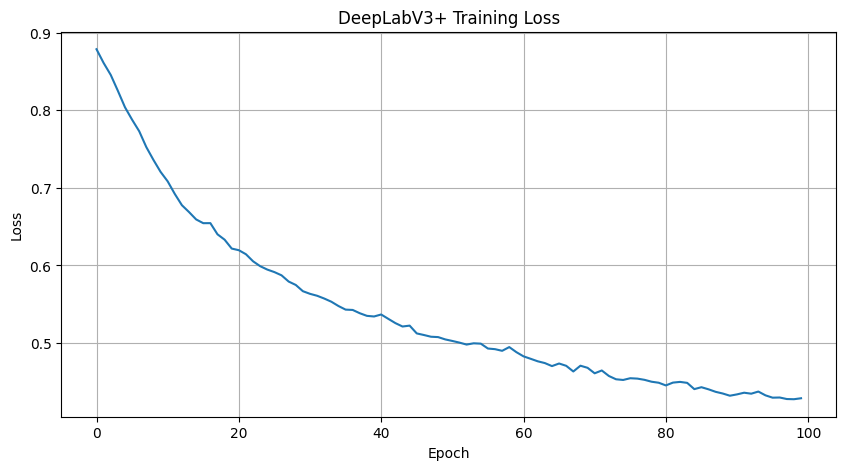


TOTAL IMAGES FOR PREDICTION: 268

PREDICTING ALL IMAGES



100%|████████████████████████████████████████████████████████████████████████████████| 268/268 [01:10<00:00,  3.82it/s]



ALL PREDICTIONS COMPLETE

VISUALIZING RESULTS

CALCULATING METRICS

MATCHED SAMPLES: 26

FINAL METRICS

IoU Score       : 0.3808
Dice Score      : 0.5485
Precision Score : 0.4330
Recall Score    : 0.7598


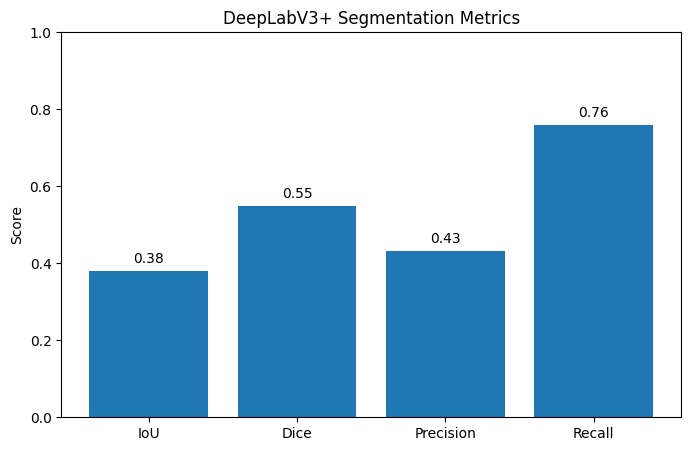


PIPELINE COMPLETE


In [4]:
# ============================================================
# COMPLETE DEEPLABV3+ FARMLAND SEGMENTATION PIPELINE
# TRAIN ON 57 IMAGES
# PREDICT ON ALL OTHER IMAGES
# METRICS + VISUALIZATION + OVERLAY
# FULLY CORRECTED VERSION
# ============================================================

# ============================================================
# INSTALL REQUIRED LIBRARIES
# ============================================================

# pip install segmentation-models-pytorch
# pip install opencv-python
# pip install matplotlib
# pip install tqdm

# ============================================================
# IMPORTS
# ============================================================

import os
import cv2
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

from glob import glob
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import segmentation_models_pytorch as smp

# ============================================================
# GPU CHECK
# ============================================================

print("\n===================================")
print("GPU CHECK")
print("===================================")

print("Torch Version:", torch.__version__)

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU:", torch.cuda.get_device_name(0))

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# PATHS
# ============================================================

# ---------------- TRAIN SET 1 ----------------

TRAIN1_IMAGES = r"D:\farmland boundary\New folder\Train\farmlands"

# ---------------- TRAIN SET 2 ----------------

TRAIN2_IMAGES = r"D:\farmland boundary\New folder\Train 2\images"

# ---------------- GT MASKS ----------------

MASK_FOLDER = r"D:\farmland boundary\all_boundary_masks"

# ---------------- ALL IMAGES TO PREDICT ----------------

PREDICT_IMAGES = r"D:\farmland boundary\New folder\images"

# ---------------- OUTPUTS ----------------

PREDICTION_FOLDER = r"D:\farmland boundary\deeplab_predictions"

OVERLAY_FOLDER = r"D:\farmland boundary\overlay_predictions"

MODEL_PATH = r"D:\farmland boundary\deeplabv3plus_boundary.pth"

os.makedirs(PREDICTION_FOLDER, exist_ok=True)

os.makedirs(OVERLAY_FOLDER, exist_ok=True)

# ============================================================
# SETTINGS
# ============================================================

IMAGE_SIZE = 768

BATCH_SIZE = 4

EPOCHS = 100

LEARNING_RATE = 1e-4

# ============================================================
# NORMALIZE FILENAMES
# ============================================================

def normalize_name(name):

    name = os.path.splitext(name)[0]

    name = name.lower()

    name = name.replace("_pred", "")

    name = name.replace("- copy", "")

    name = name.replace(" ", "")

    name = name.strip()

    return name

# ============================================================
# DATASET
# ============================================================

class FarmlandDataset(Dataset):

    def __init__(self, image_folders, mask_folder):

        self.samples = []

        # ====================================================
        # LOAD MASKS
        # ====================================================

        mask_paths = glob(
            os.path.join(mask_folder, "*.png")
        )

        mask_dict = {}

        for mask_path in mask_paths:

            key = normalize_name(
                os.path.basename(mask_path)
            )

            mask_dict[key] = mask_path

        # ====================================================
        # MATCH TRAIN IMAGES
        # ====================================================

        for folder in image_folders:

            image_paths = sorted(

                glob(os.path.join(folder, "*.jpg")) +

                glob(os.path.join(folder, "*.png")) +

                glob(os.path.join(folder, "*.jpeg"))
            )

            for image_path in image_paths:

                key = normalize_name(
                    os.path.basename(image_path)
                )

                if key in mask_dict:

                    self.samples.append(
                        (
                            image_path,
                            mask_dict[key]
                        )
                    )

        print(f"\nVALID TRAINING PAIRS: {len(self.samples)}")

        self.transform = transforms.Compose([
            transforms.ToTensor()
        ])

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        image_path, mask_path = self.samples[idx]

        # ====================================================
        # LOAD IMAGE
        # ====================================================

        image = cv2.imread(image_path)

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        # ====================================================
        # LOAD MASK
        # ====================================================

        mask = cv2.imread(mask_path, 0)

        # ====================================================
        # RESIZE
        # ====================================================

        image = cv2.resize(
            image,
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        mask = cv2.resize(
            mask,
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        # ====================================================
        # NORMALIZE
        # ====================================================

        image = self.transform(image)

        mask = torch.tensor(
            mask / 255.0
        ).float().unsqueeze(0)

        return image, mask

# ============================================================
# LOAD DATASET
# ============================================================

dataset = FarmlandDataset(

    [TRAIN1_IMAGES, TRAIN2_IMAGES],

    MASK_FOLDER
)

if len(dataset) == 0:

    raise ValueError(
        "\nNO VALID TRAINING PAIRS FOUND"
    )

# ============================================================
# DATALOADER
# ============================================================

loader = DataLoader(

    dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    drop_last=True
)

# ============================================================
# LOAD MODEL
# ============================================================

print("\n===================================")
print("LOADING DEEPLABV3+")
print("===================================")

model = smp.DeepLabV3Plus(

    encoder_name="resnet34",

    encoder_weights="imagenet",

    in_channels=3,

    classes=1
)

model = model.to(DEVICE)

print("\nMODEL DEVICE:")
print(next(model.parameters()).device)

# ============================================================
# LOSS FUNCTION
# ============================================================

loss_fn = smp.losses.DiceLoss(
    mode="binary"
)

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=LEARNING_RATE
)

# ============================================================
# TRAINING
# ============================================================

print("\n===================================")
print("TRAINING STARTED")
print("===================================\n")

loss_history = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for images, masks in loader:

        images = images.to(DEVICE)

        masks = masks.to(DEVICE)

        # ====================================================
        # FORWARD
        # ====================================================

        preds = model(images)

        # ====================================================
        # LOSS
        # ====================================================

        loss = loss_fn(preds, masks)

        # ====================================================
        # BACKPROP
        # ====================================================

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    loss_history.append(avg_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"Loss: {avg_loss:.4f}"
    )

# ============================================================
# SAVE MODEL
# ============================================================

torch.save(
    model.state_dict(),
    MODEL_PATH
)

print("\nMODEL SAVED")

# ============================================================
# TRAINING LOSS GRAPH
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(loss_history)

plt.title("DeepLabV3+ Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

# ============================================================
# LOAD ALL PREDICTION IMAGES
# ============================================================

predict_images = sorted(

    glob(os.path.join(PREDICT_IMAGES, "*.jpg")) +

    glob(os.path.join(PREDICT_IMAGES, "*.png")) +

    glob(os.path.join(PREDICT_IMAGES, "*.jpeg"))
)

print(f"\nTOTAL IMAGES FOR PREDICTION: {len(predict_images)}")

# ============================================================
# PREDICT ON ALL IMAGES
# ============================================================

print("\n===================================")
print("PREDICTING ALL IMAGES")
print("===================================\n")

model.eval()

transform = transforms.Compose([
    transforms.ToTensor()
])

with torch.no_grad():

    for image_path in tqdm(predict_images):

        image = cv2.imread(image_path)

        if image is None:
            continue

        original = image.copy()

        h, w = image.shape[:2]

        rgb = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        # ====================================================
        # RESIZE
        # ====================================================

        resized = cv2.resize(
            rgb,
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        tensor = transform(resized)

        tensor = tensor.unsqueeze(0).to(DEVICE)

        # ====================================================
        # PREDICT
        # ====================================================

        pred = model(tensor)

        pred = torch.sigmoid(pred)

        pred = pred.squeeze().cpu().numpy()

        # ====================================================
        # THRESHOLD
        # ====================================================

        pred = (pred > 0.25).astype(np.uint8)

        pred = pred * 255

        # ====================================================
        # MORPHOLOGICAL CLEANING
        # ====================================================

        kernel = np.ones((3,3), np.uint8)

        pred = cv2.morphologyEx(
            pred,
            cv2.MORPH_CLOSE,
            kernel
        )

        pred = cv2.morphologyEx(
            pred,
            cv2.MORPH_OPEN,
            kernel
        )

        # ====================================================
        # RESIZE BACK
        # ====================================================

        pred = cv2.resize(
            pred,
            (w, h)
        )

        # ====================================================
        # SAVE MASK
        # ====================================================

        filename = os.path.basename(image_path)

        pred_name = (
            os.path.splitext(filename)[0] + "_pred.png"
        )

        pred_path = os.path.join(
            PREDICTION_FOLDER,
            pred_name
        )

        cv2.imwrite(pred_path, pred)

        # ====================================================
        # CREATE OVERLAY
        # ====================================================

        overlay = cv2.cvtColor(
            original,
            cv2.COLOR_BGR2RGB
        )

        overlay[pred > 0] = [255, 0, 0]

        overlay = cv2.cvtColor(
            overlay,
            cv2.COLOR_RGB2BGR
        )

        overlay_path = os.path.join(
            OVERLAY_FOLDER,
            pred_name
        )

        cv2.imwrite(
            overlay_path,
            overlay
        )

print("\n===================================")
print("ALL PREDICTIONS COMPLETE")
print("===================================")

# ============================================================
# VISUALIZATION
# ============================================================

print("\n===================================")
print("VISUALIZING RESULTS")
print("===================================")

sample_preds = random.sample(

    glob(os.path.join(PREDICTION_FOLDER, "*.png")),

    min(5, len(glob(os.path.join(PREDICTION_FOLDER, "*.png"))))
)

for pred_path in sample_preds:

    filename = os.path.basename(pred_path)

    original_name = filename.replace("_pred.png", ".png")

    original_path = os.path.join(
        PREDICT_IMAGES,
        original_name
    )

    original = cv2.imread(original_path)

    pred = cv2.imread(pred_path, 0)

    if original is None:
        continue

    original = cv2.cvtColor(
        original,
        cv2.COLOR_BGR2RGB
    )

    # ========================================================
    # OVERLAY
    # ========================================================

    overlay = original.copy()

    overlay[pred > 0] = [255, 0, 0]

    # ========================================================
    # PLOT
    # ========================================================

    plt.figure(figsize=(18,6))

    # ORIGINAL
    plt.subplot(1,3,1)

    plt.imshow(original)

    plt.title("Original Image")

    plt.axis("off")

    # PRED MASK
    plt.subplot(1,3,2)

    plt.imshow(pred, cmap="gray")

    plt.title("Predicted Boundary Mask")

    plt.axis("off")

    # OVERLAY
    plt.subplot(1,3,3)

    plt.imshow(overlay)

    plt.title("Boundary Overlay")

    plt.axis("off")

    plt.show()

# ============================================================
# METRICS EVALUATION
# ============================================================

print("\n===================================")
print("CALCULATING METRICS")
print("===================================")

# ============================================================
# METRIC FUNCTIONS
# ============================================================

def calculate_iou(y_true, y_pred):

    intersection = np.logical_and(y_true, y_pred).sum()

    union = np.logical_or(y_true, y_pred).sum()

    if union == 0:
        return 1.0

    return intersection / union


def calculate_dice(y_true, y_pred):

    intersection = np.logical_and(y_true, y_pred).sum()

    total = y_true.sum() + y_pred.sum()

    if total == 0:
        return 1.0

    return (2 * intersection) / total


def calculate_precision(y_true, y_pred):

    tp = np.logical_and(y_true == 1, y_pred == 1).sum()

    fp = np.logical_and(y_true == 0, y_pred == 1).sum()

    if (tp + fp) == 0:
        return 1.0

    return tp / (tp + fp)


def calculate_recall(y_true, y_pred):

    tp = np.logical_and(y_true == 1, y_pred == 1).sum()

    fn = np.logical_and(y_true == 1, y_pred == 0).sum()

    if (tp + fn) == 0:
        return 1.0

    return tp / (tp + fn)

# ============================================================
# LOAD GT MASKS
# ============================================================

gt_paths = glob(
    os.path.join(MASK_FOLDER, "*.png")
)

# ============================================================
# LOAD PREDICTIONS
# ============================================================

pred_paths = glob(
    os.path.join(PREDICTION_FOLDER, "*.png")
)

pred_dict = {}

for pred_path in pred_paths:

    key = normalize_name(
        os.path.basename(pred_path)
    )

    pred_dict[key] = pred_path

# ============================================================
# STORAGE
# ============================================================

ious = []
dices = []
precisions = []
recalls = []

matched = 0

# ============================================================
# LOOP THROUGH GT
# ============================================================

for gt_path in gt_paths:

    gt_name = normalize_name(
        os.path.basename(gt_path)
    )

    if gt_name not in pred_dict:

        continue

    pred_path = pred_dict[gt_name]

    matched += 1

    gt = cv2.imread(gt_path, 0)

    pred = cv2.imread(pred_path, 0)

    pred = cv2.resize(
        pred,
        (gt.shape[1], gt.shape[0])
    )

    gt = (gt > 127).astype(np.uint8)

    pred = (pred > 127).astype(np.uint8)

    ious.append(
        calculate_iou(gt, pred)
    )

    dices.append(
        calculate_dice(gt, pred)
    )

    precisions.append(
        calculate_precision(gt, pred)
    )

    recalls.append(
        calculate_recall(gt, pred)
    )

print(f"\nMATCHED SAMPLES: {matched}")

# ============================================================
# FINAL METRICS
# ============================================================

avg_iou = np.mean(ious)

avg_dice = np.mean(dices)

avg_precision = np.mean(precisions)

avg_recall = np.mean(recalls)

print("\n===================================")
print("FINAL METRICS")
print("===================================\n")

print(f"IoU Score       : {avg_iou:.4f}")

print(f"Dice Score      : {avg_dice:.4f}")

print(f"Precision Score : {avg_precision:.4f}")

print(f"Recall Score    : {avg_recall:.4f}")

# ============================================================
# METRICS BAR GRAPH
# ============================================================

metrics = [
    "IoU",
    "Dice",
    "Precision",
    "Recall"
]

values = [
    avg_iou,
    avg_dice,
    avg_precision,
    avg_recall
]

plt.figure(figsize=(8,5))

bars = plt.bar(metrics, values)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("DeepLabV3+ Segmentation Metrics")

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.2f}",
        ha='center'
    )

plt.show()

print("\n===================================")
print("PIPELINE COMPLETE")
print("===================================")